In [1]:
import pandas as pd
import numpy as np

print("Precision Irrigation Module Started")

Precision Irrigation Module Started


In [2]:
sensor = pd.read_csv("../dataset/final_crop_health_dataset.csv")

sensor.head()

,farm_id,region,crop,soil_moisture,soil_ph,temperature,rainfall,humidity,sunlight_hours,irrigation_type,...,longitude,ndvi,crop_disease_status,soil_fertility_score,weather_score,vegetation_score,moisture_stress_score,ai_crop_health_index,health_status,irrigation_recommendation
0,FARM0001,North India,Wheat,0.740666,0.241206,0.140625,0.102295,0.739401,0.544240,Sprinkler,...,82.997689,0.550000,Mild,0.490936,0.327440,0.550000,0.421481,0.450937,Moderate,No Irrigation Needed
1,FARM0002,South USA,Soybean,0.275129,0.869347,0.765121,0.159733,0.419932,0.277129,Sprinkler,...,70.869009,0.466667,Severe,0.572238,0.448262,0.466667,0.217431,0.443890,Moderate,High Irrigation
2,FARM0003,South USA,Wheat,0.550258,0.829146,0.623488,0.865228,0.575447,0.704508,Drip,...,79.068206,0.833333,Mild,0.689702,0.688054,0.833333,0.707743,0.728806,Good,Moderate Irrigation
3,FARM0004,Central USA,Maize,0.205916,0.261307,0.944052,0.650508,0.607394,0.170284,Sprinkler,...,85.519998,0.233333,Severe,0.233611,0.733985,0.233333,0.428212,0.397555,Poor,High Irrigation
4,FARM0005,Central USA,Cotton,0.264503,0.206030,0.950605,0.879939,0.311433,0.654424,Sprinkler,...,81.691720,0.900000,Severe,0.235267,0.713992,0.900000,0.572221,0.588522,Moderate,High Irrigation


In [3]:
def irrigation_level(row):

    if row["ai_crop_health_index"] >= 0.80:
        return "No Irrigation Required"

    elif row["ai_crop_health_index"] >= 0.60:
        return "Low Irrigation"

    elif row["ai_crop_health_index"] >= 0.40:
        return "Medium Irrigation"

    else:
        return "High Irrigation"

sensor["irrigation_level"] = sensor.apply(
    irrigation_level,
    axis=1
)

sensor[[
    "crop",
    "ai_crop_health_index",
    "irrigation_level"
]].head()

,crop,ai_crop_health_index,irrigation_level
0,Wheat,0.450937,Medium Irrigation
1,Soybean,0.443890,Medium Irrigation
2,Wheat,0.728806,Low Irrigation
3,Maize,0.397555,High Irrigation
4,Cotton,0.588522,Medium Irrigation


In [4]:
print(sensor["irrigation_level"].value_counts())

irrigation_level
Medium Irrigation         266
High Irrigation           115
Low Irrigation            113
No Irrigation Required      6
Name: count, dtype: int64


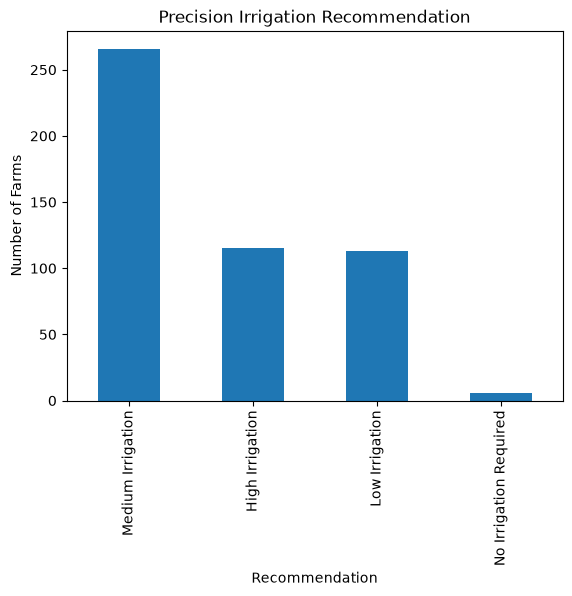

In [5]:
import matplotlib.pyplot as plt

sensor["irrigation_level"].value_counts().plot(kind="bar")

plt.title("Precision Irrigation Recommendation")

plt.xlabel("Recommendation")

plt.ylabel("Number of Farms")

plt.show()

In [6]:
sensor.to_csv(
    "../dataset/final_irrigation_dataset.csv",
    index=False
)

print("Final Irrigation Dataset Saved Successfully!")

Final Irrigation Dataset Saved Successfully!
